# Data Augmentation

This notebook generates synthetic linear voltammogram data in the concentration interval **[7.5, 20] µM** and evaluates whether the increased data volume improves model accuracy.

To do: experimenting with full concentration interval, since after 25 µM there are greater gaps in the data (note: Ip ratio is 1.5x despite 2x concentration jump in 50 to 100µM, linear interpolation will be aproximate, could lead to false records)

### Workflow
1. **Physics-Informed Augmentation**: Interpolation, Gaussian noise, baseline variation, potential drift  
2. **Feature Extraction**: Route synthetic signals through the existing `Signal` + `vectorize` pipeline  
3. **Model Comparison**: Original vs. augmented dataset across all three feature categories  


In [16]:
# imports
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# filter used for smoothing the voltammogram signals
from scipy.signal import savgol_filter

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# project specific classes
from voltammogram_signal import Signal
from peak import Peak

warnings.filterwarnings('ignore')

# for reproducibility
np.random.seed(42) 


---
## 1 · Load Data


In [17]:
DATASET_PATH = 'datasets/Standard calibration in culture media_extended.xlsx'

df_raw = pd.read_excel(DATASET_PATH, sheet_name='Raw data')

# row 0 contains units, data starts at row 1
E_global = df_raw.iloc[1:, 0].values.astype(float) # potential array (V)
I_baseline_raw = df_raw.iloc[1:, 1].values.astype(float) # blank / baseline (µA)
signals_raw = df_raw.iloc[1:, 2:].values.astype(float)  # all signal columns (µA)

CONCENTRATIONS = [
    100, 100, 100,
    50,  50,  50,
    25,  25,  25,
    15,  15,  15,
    10,  10,  10,
    7.5, 7.5, 7.5,
    5,   5,   5,
    2.5, 2.5,
    1,   1,   1,
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
    0.25, 0.25, 0.25,
    0.1,  0.1,  0.1,  0.1,  0.1
]   # length = 40 (one entry per signal column)

print(f"Potential range  : {E_global.min():.4f} V  ->  {E_global.max():.4f} V")
print(f"Number of points : {len(E_global)}")
print(f"Signal columns   : {signals_raw.shape[1]}")


Potential range  : -0.6001 V  ->  0.5023 V
Number of points : 229
Signal columns   : 40


**Target interval**: [7.5, 20] µM  
**Base curves**: mean of 3 replicates at 7.5, 10, and 15 µM (after baseline subtraction).

Each synthetic sample is produced by:
1. **Concentration interpolation**: linear mix of the two bounding mean curves, peak current scaled proportionally to concentration (example: a 12µM reading generated using data from 10µM and 15µM by making a new curve) 
2. **Gaussian noise**: white noise with σ = 0.001 µA (strictly limited to preserve chemical validity) 
3. **Baseline variation**: low-order polynomial added to simulate capacitive background distortions (basically see what happens if the base- filler signal varries)
4. **Potential drift**: X-axis shift drawn from *N*(0, σ_drift), σ_drift ~ *U*(0.01, 0.03) (future: can be tested with the dilution dataset)


In [18]:
# build mean base curves for 7.5, 10, 15 µM
def mean_baseline_subtracted(signals_matrix, I_baseline, concentrations, target_uM):
    """Return mean baseline-subtracted signal across all replicates at target_uM."""
    
    # indexes for the target concentration
    idxs = [i for i, c in enumerate(concentrations) if c == target_uM]
    
    # subtract baseline to keep only the reaction signal
    I_subs = [signals_matrix[:, i] - I_baseline for i in idxs]
    return np.mean(I_subs, axis=0)

base_75 = mean_baseline_subtracted(signals_raw, I_baseline_raw, CONCENTRATIONS,  7.5)
base_10 = mean_baseline_subtracted(signals_raw, I_baseline_raw, CONCENTRATIONS, 10.0)
base_15 = mean_baseline_subtracted(signals_raw, I_baseline_raw, CONCENTRATIONS, 15.0)

# Ip should scale proportionally with concentration
for label, curve in [('7.5 uM', base_75), ('10 uM', base_10), ('15 uM', base_15)]:
    pk = Peak(E_global, savgol_filter(curve, 5, 3))
    # ip is the maximum current, ep is the potential at which it occurs
    print(f"  {label:6s}  Ip = {pk.Ip:.4f} uA   Ep = {pk.Ep:.4f} V")


  7.5 uM  Ip = 2.7481 uA   Ep = -0.3970 V
  10 uM   Ip = 4.0259 uA   Ep = -0.3922 V
  15 uM   Ip = 6.1034 uA   Ep = -0.3873 V


In [19]:
# Concentration Interpolation / Scaling 
def get_base_pair(c_target):
    """Return (c_low, I_low, c_high, I_high) bracketing c_target in [7.5, 20].
    Basically, if we need data for 12 uM, we interpolate between the 10 and 15 uM base curves. 
    If we need 8 uM, we interpolate between the 7.5 and 10 uM curves. 
    For concentrations above 15 uM, we can extrapolate using the 10 and 15 uM curves as a reference.
    """
    if c_target <= 10.0:
        return 7.5, base_75, 10.0, base_10
    elif c_target <= 15.0:
        return 10.0, base_10, 15.0, base_15
    else:
        # Linear extrapolation beyond 15 uM using the 10->15 trend
        return 10.0, base_10, 15.0, base_15

    

def interpolate_base_curve(c_target, c_low, I_low, c_high, I_high):
    """
    Linearly interpolate between two base curves so the peak current
    scales proportionally to concentration.
    We calculate the alpha factor (a percentage) that tells us how far c_target is between c_low and c_high,
    For a 12 um curve, how much of the 10um curve and how much of the 15um curve we need to mix to get the curve for the new concentration.
    """
    if c_high == c_low:
        # avoid div by 0, using copy to prevent modifying original arrays
        return I_low.copy()
    # procentile distance of c_target between c_low and c_high
    # For example, if c_target is 12 uM, c_low is 10 uM and c_high is 15 uM, then alpha = (12 - 10) / (15 - 10) = 0.4
    alpha = (c_target - c_low) / (c_high - c_low)
    # return the weighted average of the two curves
    # knowing alpha = 0.4, we would take 60% of the 10 uM curve and 40% of the 15 uM curve to get the 12 uM curve
    return (1.0 - alpha) * I_low + alpha * I_high

# Gaussian Noise 
# uA is strictly limited to preserve chemical validity
NOISE_SIGMA = 0.001

def add_gaussian_noise(I, sigma=NOISE_SIGMA):
    # amount of noise values to add is exactly how many points we have in the signal
    return I + np.random.normal(0.0, sigma, size=I.shape)


### Baseline variation
Current potential range: -0.6001 V -> 0.5023 V
Exploring an example with and without normalization

Without normalization:
- left (-0.6V): $(-0.6)^2 - (-0.6)^4 = 0.36 - 0.1296 = \mathbf{0.2304}$
- right (+0.5V): $(0.5)^2 - (0.5)^4 = 0.25 - 0.0625 = \mathbf{0.1875}$

As such distortion will be asymetrical without normalization, it would ruin the horisontal aligmnent.

With normalization (using E.max as 0.5V, E.min as -0.6V and E.mean as -0.05V):
- E_norm = (E - E.mean()) / (E.max() - E.min())

- left (-0.6V): $(-0.6 - (-0.05)) / 1.1 = -0.55 / 1.1 = \mathbf{-0.5}$
- right (+0.5V):  $(0.5 - (-0.05)) / 1.1 = 0.55 / 1.1 = \mathbf{+0.5}$
- mid: $(-0.05 - (-0.05)) / 1.1 = \mathbf{0.0}$

As such, the distortion will be simetrical


In [20]:
# Baseline Variation
def add_baseline_variation(I, E, max_amp=0.05):
    """
    Adds a smooth polynomial distortion to simulate baseline drift.
    Anchored to zero at the potential extremes to avoid DC offset shift.
    """
    # random distortion
    amp = np.random.uniform(-max_amp, max_amp)
    # normalize E to [-1, 1] for stable polynomial shaping
    E_norm = (E - E.mean()) / (E.max() - E.min())

    # distortion shape: a simple 4th degree polynomial that creates a smooth bump or dip in the baseline
    distortion = amp * (E_norm ** 2 - E_norm ** 4)
    return I + distortion

(The interpolation function keeps the shifted graph, rereading through the same sensors)

When physical potential drift occurs (example: iR-drop), the signal shifts along the X-axis, but the instrument's sampling grid remains fixed. 

Applying a horizontal shift and then use interpolation to resample the shifted curve back onto the original voltage grid. 
The same chemical signature is now represented by a new array of values. This creates a focus on the features of the reaction peak rather than the coordinate index.

Example: E = [1, 2, 3, 4, 5] (fixed grid)
I_original = [0, 0, 10, 0, 0] . with a 10ua peak

E_shifted = [2, 3, 4, 5, 6] (delayed reaction)
I_augmented = [0, 0, 0, 10, 0] (by applying interpolation we map the peak differently)

In [21]:
# Potential Drift (iR-drop simulation) 
def apply_potential_drift(I, E, sigma_low=0.01, sigma_high=0.03):
    """
    Shifts the signal along the potential axis by delta_E ~ N(0, sigma_drift),
    sigma_drift ~ U(sigma_low, sigma_high).
    Re-interpolates back onto the original E grid.
    """
    sigma_drift = np.random.uniform(sigma_low, sigma_high)
    delta_E = np.random.normal(0.0, sigma_drift)
    E_shifted = E + delta_E
    return np.interp(E, E_shifted, I, left=I[0], right=I[-1])

In [ ]:
N_SYNTHETIC = 90 # aprox 3 samples per 0.5 uM step across [7.5, 20]

def generate_synthetic_signal(c_target):
    """Full augmentation pipeline for one synthetic sample."""
    c_low, I_low, c_high, I_high = get_base_pair(c_target)
    # try individual and see changes*
    I = interpolate_base_curve(c_target, c_low, I_low, c_high, I_high) 
    I = add_gaussian_noise(I)
    I = add_baseline_variation(I, E_global)
    I = apply_potential_drift(I, E_global)
    return I

# Sample concentrations uniformly in [7.5, 20] uM
aug_concentrations = np.sort(np.random.uniform(7.5, 20.0, size=N_SYNTHETIC))
aug_signals_I      = [generate_synthetic_signal(c) for c in aug_concentrations]

print(f"Generated {len(aug_signals_I)} synthetic signals")
print(f"Concentration range: {aug_concentrations.min():.2f} – {aug_concentrations.max():.2f} uM")


Generated 90 synthetic signals
Concentration range: 7.57 – 19.84 uM


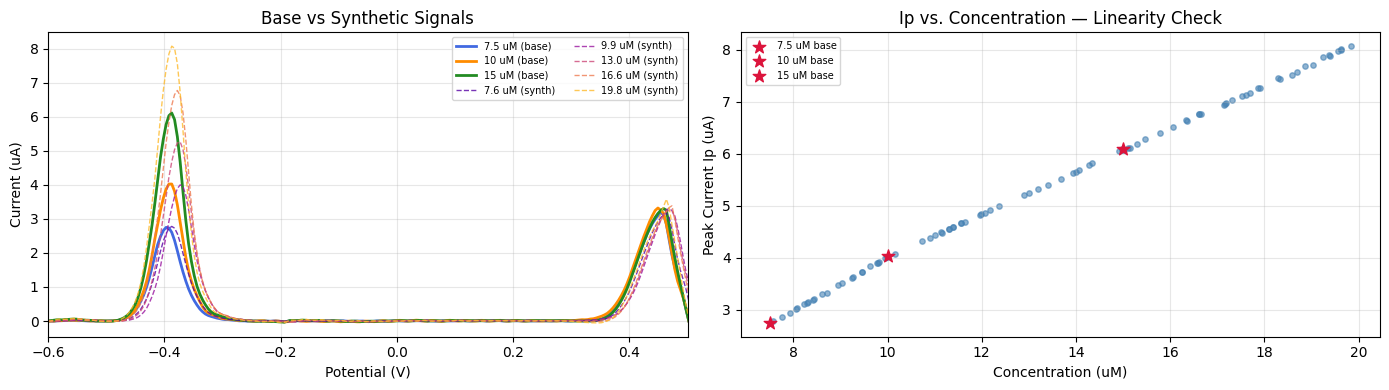

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(E_global, base_75,  color='royalblue',   lw=2.0, label='7.5 uM (base)')
ax.plot(E_global, base_10,  color='darkorange',  lw=2.0, label='10 uM (base)')
ax.plot(E_global, base_15,  color='forestgreen', lw=2.0, label='15 uM (base)')
sample_idxs  = np.linspace(0, N_SYNTHETIC - 1, 5, dtype=int)
colors_synth = plt.cm.plasma(np.linspace(0.15, 0.85, 5))
for k, idx in enumerate(sample_idxs):
    c = aug_concentrations[idx]
    ax.plot(E_global, aug_signals_I[idx], '--', lw=1.0,
            color=colors_synth[k], alpha=0.8, label=f'{c:.1f} uM (synth)')
ax.set_xlim(-0.6, 0.5)
ax.set_xlabel('Potential (V)')
ax.set_ylabel('Current (uA)')
ax.set_title('Base vs Synthetic Signals')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
Ip_synth = [Peak(E_global, savgol_filter(I, 5, 3)).Ip for I in aug_signals_I]
ax2.scatter(aug_concentrations, Ip_synth, s=15, alpha=0.6, color='steelblue')
for c_b, I_b, lbl in [(7.5, base_75, '7.5'), (10.0, base_10, '10'), (15.0, base_15, '15')]:
    pk = Peak(E_global, savgol_filter(I_b, 5, 3))
    ax2.scatter([c_b], [pk.Ip], s=90, zorder=5, marker='*', color='crimson', label=f'{lbl} uM base')
ax2.set_xlabel('Concentration (uM)')
ax2.set_ylabel('Peak Current Ip (uA)')
ax2.set_title('Ip vs. Concentration — Linearity Check')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 3 · Feature Extraction Pipeline

Synthetic signals are routed through the same Signal + vectorize pipeline used in feature_extraction.ipynb.

 **Note**: Augmented signals are already baseline-subtracted. We temporarily clear Signal.I_baseline before processing them, then restore it.


In [24]:
def vectorize(sig, job='core'):
    v = []
    if job in ['core', 'extended', 'experimental']:
        v += [sig.get_peak_current_value(),
              sig.get_peak_potential_value(),
              sig.get_peak_auc(),
              sig.get_peak_fwhm()]
    if job in ['extended', 'experimental']:
        v += [sig.get_pca1_comp(),
              sig.get_first_derivative_max(),
              sig.get_second_derivative_min()]
    if job == 'experimental':
        v += [sig.get_left_slope(),
              sig.get_right_slope(),
              sig.get_asymetry(),
              sig.get_peak_sharpness(),
              sig.get_peak_compactness(),
              sig.get_current_variance(),
              sig.get_peak_skewness(),
              sig.get_peak_kurtosis(),
              sig.get_tchebichef_curve_moments(),
              sig.get_mean_peak(),
              sig.get_signal_entropy(),
              sig.get_spectral_entropy(),
              sig.get_fft_power(),
              sig.get_pca2_comp(),
              sig.get_pca3_comp(),
              sig.get_wavelet_energy()]
    return v


FEATURE_COLS = {
    'core':         ['peak_current', 'peak_potential', 'peak_AUC', 'peak_FWHM'],
    'extended':     ['peak_current', 'peak_potential', 'peak_AUC', 'peak_FWHM',
                     'pca1_comp', 'first_derivative_max', 'second_derivative_min'],
    'experimental': ['peak_current', 'peak_potential', 'peak_AUC', 'peak_FWHM',
                     'pca1_comp', 'first_derivative_max', 'second_derivative_min',
                     'left_slope', 'right_slope', 'asymetry', 'peak_sharpness',
                     'peak_compactness', 'current_variance', 'peak_skewness',
                     'peak_kurtosis', 'tchebichef_curve_moments', 'mean_peak',
                     'signal_entropy', 'spectral_entropy', 'fft_power',
                     'pca2_comp', 'pca3_comp', 'wavelet_energy'],
}


In [25]:
# Process ORIGINAL signals
Signal.set_common_potential_E(E_global)
Signal.set_common_baseline_I(I_baseline_raw)
Signal.sig_id = 1

orig_signals = []
for i in range(signals_raw.shape[1]):
    try:
        sig = Signal(signals_raw[:, i])
        orig_signals.append((sig, CONCENTRATIONS[i]))
    except Exception as e:
        print(f"  [WARN] signal {i} skipped: {e}")

print(f"Original signals processed: {len(orig_signals)}")


Original signals processed: 40


In [26]:
# Process AUGMENTED signals
# Augmented signals are already baseline-subtracted; disable auto-subtraction.
Signal.set_common_baseline_I(np.array([]))

aug_signal_objects, skipped = [], 0
for I_syn, c_syn in zip(aug_signals_I, aug_concentrations):
    try:
        sig = Signal(I_syn)
        aug_signal_objects.append((sig, float(c_syn)))
    except Exception:
        skipped += 1

Signal.set_common_baseline_I(I_baseline_raw) # restore

print(f"Augmented signals processed: {len(aug_signal_objects)}  (skipped: {skipped})")


Augmented signals processed: 90  (skipped: 0)


In [27]:
# DataFrames for all three feature suites
def build_dataframe(signal_list, job):
    rows = []
    for sig, conc in signal_list:
        try:
            rows.append(vectorize(sig, job=job) + [conc])
        except Exception:
            pass
    return pd.DataFrame(rows, columns=FEATURE_COLS[job] + ['concentration'])


orig_core = build_dataframe(orig_signals, 'core')
orig_ext  = build_dataframe(orig_signals, 'extended')
orig_exp  = build_dataframe(orig_signals, 'experimental')

aug_core  = build_dataframe(aug_signal_objects, 'core')
aug_ext   = build_dataframe(aug_signal_objects, 'extended')
aug_exp   = build_dataframe(aug_signal_objects, 'experimental')

combined_core = pd.concat([orig_core, aug_core], ignore_index=True)
combined_ext  = pd.concat([orig_ext,  aug_ext],  ignore_index=True)
combined_exp  = pd.concat([orig_exp,  aug_exp],  ignore_index=True)

print(f"Original - core: {orig_core.shape}  | extended: {orig_ext.shape}  | experimental: {orig_exp.shape}")
print(f"Combined - core: {combined_core.shape}  | extended: {combined_ext.shape}  | experimental: {combined_exp.shape}")


Original - core: (40, 5)  | extended: (40, 8)  | experimental: (40, 24)
Combined - core: (103, 5)  | extended: (103, 8)  | experimental: (103, 24)


In [28]:
# persist feature CSVs
os.makedirs('vectorized', exist_ok=True)
for name, df in [('augmented_core', aug_core), ('augmented_extended', aug_ext),
                 ('augmented_experimental', aug_exp),
                 ('combined_core', combined_core), ('combined_extended', combined_ext),
                 ('combined_experimental', combined_exp)]:
    df.to_csv(f'vectorized/{name}.csv', index=False)
print("Saved augmented and combined CSVs to vectorized/")


Saved augmented and combined CSVs to vectorized/


---
## 4 · Model Evaluation & Comparison

### Evaluation Protocols

| Protocol | Description |
|---|---|
| **A** | LOOCV on original data only (40 samples) - baseline |
| **B** | LOOCV on combined dataset (original + synthetic) |
| **C** | Leave out one original sample; train on remaining originals + ALL synthetic (conservative, unbiased) |

**Protocol C** is the scientifically cleanest comparison since synthetic samples never appear in the test set.

**Protocol B** runs high risk of data leakage, counter-example of data augumentation (the test signal could be an augumented 10uM with some noise, but in training the model receives the source signal from which the augumented one was derived)


In [ ]:
from sklearn.base import clone # for clean model at each step

MODELS = {
    'Ridge': Ridge(alpha=0.1, fit_intercept=False, random_state=42),
    'DecisionTree': DecisionTreeRegressor(max_depth=None, min_samples_split=2, 
                                          min_samples_leaf=1, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=500, max_depth=9, 
                                          max_features=0.75, min_samples_split=2, 
                                          min_samples_leaf=1, random_state=42, n_jobs=-1),
    'XGBoost':  XGBRegressor(n_estimators=235, max_depth=3, learning_rate=0.0698,
                            subsample=0.7682, colsample_bytree=0.9395, 
                            gamma=0.3391, min_child_weight=3,
                            random_state=42, verbosity=0, n_jobs=-1),
}

# can't use cross_val_score with LOOCV because of the small sample size (data leak risk)
# and the need for custom train/test splits in Protocol C, 
# so we implement LOOCV manually in the next function
def loocv_metrics(X, y, model):
    """LOOCV on a single dataset; returns MAE, RMSE, R2."""
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    # tr is the index of the training samples, te is the index of the test sample
    for tr, te in loo.split(X):
        m = clone(model)
        m.fit(X.iloc[tr], y.iloc[tr])
        # predict on the held-out sample and store the true vs predicted values
        y_pred.append(m.predict(X.iloc[te])[0])
        y_true.append(y.iloc[te].iloc[0])
    yt, yp = np.array(y_true), np.array(y_pred)
    # return a dictionary of the three metrics
    return dict(MAE=mean_absolute_error(yt, yp),
                RMSE=np.sqrt(mean_squared_error(yt, yp)),
                R2=r2_score(yt, yp))


# for Protocol C, we need to implement a custom LOOCV where the training set includes all
#  augmented samples plus all original samples except the one held out for testing. 
# This way, we can evaluate how well the augmented data helps in predicting unseen original samples.
def aug_train_metrics(X_orig, y_orig, X_aug, y_aug, model):
    """
    Protocol C: hold out each original sample in turn; train on the remaining
    original samples + the full synthetic set; test on the held-out original.
    """
    n = len(X_orig)
    y_true, y_pred = [], []
    # test_idx is the index of the original sample we hold out for testing;
    for test_idx in range(n):
        #  mask_train are the indexes of the original samples we keep for training 
        mask_train = [i for i in range(n) if i != test_idx]

        # combine original training samples with all augmented samples to form the training set
        X_tr = pd.concat([X_orig.iloc[mask_train], X_aug], ignore_index=True)
        y_tr = pd.concat([y_orig.iloc[mask_train], y_aug], ignore_index=True)
        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred.append(m.predict(X_orig.iloc[[test_idx]])[0])
        y_true.append(y_orig.iloc[test_idx])
    yt, yp = np.array(y_true), np.array(y_pred)
    return dict(MAE=mean_absolute_error(yt, yp),
                RMSE=np.sqrt(mean_squared_error(yt, yp)),
                R2=r2_score(yt, yp))


print("Evaluation helpers ready.")


Evaluation helpers ready.


In [ ]:
SUITES = {
    'core': (orig_core, combined_core, aug_core),
    'extended': (orig_ext, combined_ext, aug_ext),
    'experimental': (orig_exp, combined_exp, aug_exp),
}

results = []
for suite, (orig_df, comb_df, aug_df) in SUITES.items():
    fcols = FEATURE_COLS[suite]
    # X = features, y = target variable (concentration) for each dataset
    X_o, y_o = orig_df[fcols], orig_df['concentration']
    X_c, y_c = comb_df[fcols], comb_df['concentration']
    X_a, y_a = aug_df[fcols],  aug_df['concentration']

    # for each data packages, evaluate all models on Protocols A, B and C
    for mname, model in MODELS.items():
        print(f"  {suite:13s} | {mname:14s} ...", end=' ', flush=True)
        # protocol A: only original data
        mA = loocv_metrics(X_o, y_o, model)
        # protocol B: combined original + augmented data) (risk of data leak, to be observed)
        mB = loocv_metrics(X_c, y_c, model)
        # protocol C: augmented training (testing with original samples only)
        mC = aug_train_metrics(X_o, y_o, X_a, y_a, model)
        results.append({
            'Feature Suite': suite,
            'Model': mname,
            '[A] Orig MAE': round(mA['MAE'], 4),
            '[A] Orig RMSE':round(mA['RMSE'], 4),
            '[A] Orig R2': round(mA['R2'], 4),
            '[B] Comb MAE': round(mB['MAE'], 4),
            '[B] Comb RMSE': round(mB['RMSE'], 4),
            '[B] Comb R2': round(mB['R2'], 4),
            '[C] AugTrain MAE': round(mC['MAE'],4),
            '[C] AugTrain RMSE': round(mC['RMSE'], 4),
            '[C] AugTrain R2': round(mC['R2'], 4),
        })
        print("done")

results_df = pd.DataFrame(results)
print("\nAll evaluations complete.")


  core          | Ridge          ... 

done
  core          | DecisionTree   ... done
  core          | RandomForest   ... done
  core          | XGBoost        ... done
  extended      | Ridge          ... done
  extended      | DecisionTree   ... done
  extended      | RandomForest   ... done
  extended      | XGBoost        ... done
  experimental  | Ridge          ... done
  experimental  | DecisionTree   ... done
  experimental  | RandomForest   ... done
  experimental  | XGBoost        ... done

All evaluations complete.


In [41]:
# Comparison Table
print("=" * 110)
print("PERFORMANCE COMPARISON — Original vs Augmented Training")
print("=" * 110)
print("A = LOOCV on original only  |  B = LOOCV on combined  |  C = Orig held-out / Aug-augmented training")
print("=" * 110)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

results_df.to_csv('augumented_data_results.csv', index=False)


PERFORMANCE COMPARISON — Original vs Augmented Training
A = LOOCV on original only  |  B = LOOCV on combined  |  C = Orig held-out / Aug-augmented training


,Feature Suite,Model,[A] Orig MAE,[A] Orig RMSE,[A] Orig R2,[B] Comb MAE,[B] Comb RMSE,[B] Comb R2,[C] AugTrain MAE,[C] AugTrain RMSE,[C] AugTrain R2
0,core,Ridge,1.0618,1.8811,0.9953,0.6924,1.3691,0.9938,1.2146,2.1231,0.9940
1,core,DecisionTree,0.0625,0.3953,0.9998,0.1050,0.1894,0.9999,0.0350,0.0986,1.0000
2,core,RandomForest,0.9875,2.2354,0.9934,0.3906,1.3975,0.9936,0.8535,2.2369,0.9933
3,core,XGBoost,2.9404,6.8252,0.9380,1.1287,3.9480,0.9486,2.5644,6.3248,0.9468
4,extended,Ridge,1.4705,2.2807,0.9931,0.7367,1.5144,0.9924,1.2728,2.3600,0.9926
5,extended,DecisionTree,0.0100,0.0461,1.0000,0.1036,0.1690,0.9999,0.0545,0.1327,1.0000
6,extended,RandomForest,1.1432,2.9189,0.9887,0.4990,1.8664,0.9885,1.1340,2.9910,0.9881
7,extended,XGBoost,2.0778,4.6328,0.9714,0.8204,2.6869,0.9762,1.7966,4.2976,0.9754
8,experimental,Ridge,0.6309,1.0385,0.9986,0.3274,0.6867,0.9984,0.5830,1.0683,0.9985
9,experimental,DecisionTree,0.0625,0.3260,0.9999,0.2022,0.4102,0.9994,0.1277,0.4357,0.9997


NOTE: best result using core features and decisionTree, RMSE went from 0.39 to 0.09, R2 from 0.9934 to 0.9933 :)

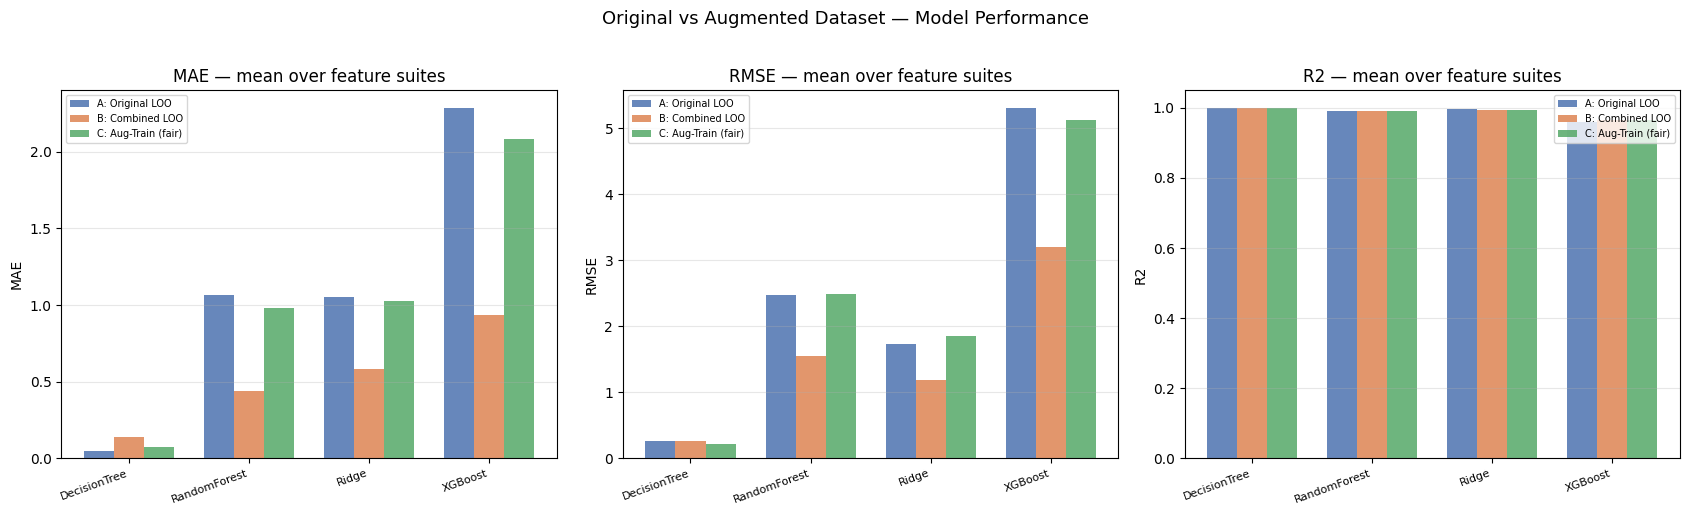

In [42]:
# Visual Summary
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metric_map = {
    'MAE':  (['[A] Orig MAE',  '[B] Comb MAE',  '[C] AugTrain MAE'],  False),
    'RMSE': (['[A] Orig RMSE', '[B] Comb RMSE', '[C] AugTrain RMSE'], False),
    'R2':   (['[A] Orig R2',   '[B] Comb R2',   '[C] AugTrain R2'],   True),
}
colors = ['#4C72B0', '#DD8452', '#55A868']
proto_labels = ['A: Original LOO', 'B: Combined LOO', 'C: Aug-Train (fair)']

for ax, (metric, (cols, _)) in zip(axes, metric_map.items()):
    agg = results_df.groupby('Model')[cols].mean().reset_index()
    x = np.arange(len(agg))
    w = 0.25
    for j, (col, color) in enumerate(zip(cols, colors)):
        ax.bar(x + j * w, agg[col], width=w, label=proto_labels[j],
               color=color, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(agg['Model'], rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — mean over feature suites')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Original vs Augmented Dataset — Model Performance', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
